# 211 Call Volume Forecasting

**Goal:** Forecast daily 211 call center volume  
**Data:** `211FactCalls.csv` — 333,741 call records from January 2019 to June 2026.  
**Models:** Prophet, SARIMA, XGBoost

In [170]:
# Cell 1 — Install required packages (run once, then restart kernel)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'prophet', 'xgboost', 'pmdarima', 'holidays'], check=True)
print()
print('=' * 60)
print('Packages installed. RESTART THE KERNEL before running the rest.')
print('Kernel menu → Restart Kernel (or press 0, 0 in classic Notebook)')
print('=' * 60)


Packages installed. RESTART THE KERNEL before running the rest.
Kernel menu → Restart Kernel (or press 0, 0 in classic Notebook)


## 1. Setup & Imports

In [171]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import holidays

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

DATA_PATH = r'C:\Users\powerbi\211 Call Volume Forecasting\211FactCalls.csv'

print('All imports successful.')
print(f'XGBoost {xgb.__version__} | pmdarima {pm.__version__} | Prophet loaded')

All imports successful.
XGBoost 3.2.0 | pmdarima 2.1.1 | Prophet loaded


## 2. Data Loading & Exploratory Data Analysis

In [172]:
# Load only needed columns to keep memory footprint small
df_raw = pd.read_csv(
    DATA_PATH,
    usecols=['InteractionDate', 'CallType', 'Status', 'State', 'InteractionHourKey'],
    parse_dates=['InteractionDate'],
    dtype={'State': 'category', 'CallType': 'category', 'Status': 'category'},
    low_memory=False
)

# Salesforce exports DateTime in UTC — convert to Mountain Time (handles MST/MDT automatically)
df_raw['InteractionDate'] = (
    df_raw['InteractionDate']
    .dt.tz_localize('UTC')         # label these timestamps as UTC
    .dt.tz_convert('US/Mountain')  # shift to Mountain Time (UTC-7 MST, UTC-6 MDT)
    .dt.tz_localize(None)          # strip the timezone label so downstream code stays simple
)

print(f'Loaded {len(df_raw):,} records')
print(f'Date range: {df_raw["InteractionDate"].min().date()} to {df_raw["InteractionDate"].max().date()}')
print(f'\nCallType distribution:')
print(df_raw['CallType'].value_counts().to_string())

Loaded 405,267 records
Date range: 2019-01-01 to 2026-06-16

CallType distribution:
CallType
Assessment and Referral        169939
Information                    124483
VITA                            29443
No Answer                       23091
Hang Up                         20766
RUTA                            10525
Wrong Number                     8414
Callback - No Answer             7759
Static                           2147
Prank Call                       1399
Duplicated                        675
Crisis Call                       201
SUD Hotline                       118
Disaster Information               60
Diabetes Prevention Program         9
Child Tax Credit                    1


In [173]:
df_hourly = (
    df_raw
    .groupby(df_raw['InteractionDate'].dt.floor('h'))
    .size()
    .reset_index(name='y')
    .rename(columns={'InteractionDate': 'ds'})
)

# Fill in hours with zero calls (important — gaps ≠ missing data, they're real zeros)
full_range = pd.date_range(
    start=df_hourly['ds'].min(),
    end=df_hourly['ds'].max(),
    freq='h'
)
df_hourly = df_hourly.set_index('ds').reindex(full_range, fill_value=0).reset_index()
df_hourly.columns = ['ds', 'y']

print(f'Hourly series: {len(df_hourly):,} rows')
print(f'Date range: {df_hourly["ds"].min()} to {df_hourly["ds"].max()}')
print(f'Zero-call hours: {(df_hourly["y"] == 0).sum():,}')

Hourly series: 65,370 rows
Date range: 2019-01-01 00:00:00 to 2026-06-16 17:00:00
Zero-call hours: 29,809


In [174]:
# Confirmed data errors — drop these dates entirely so Prophet bridges over them naturally
BAD_DATES = pd.to_datetime([
    # Dec 2022: system failed to log calls Dec 1–12 with correct timestamps;
    # all were bulk-dumped onto Dec 13 (2,115 calls). Entire range is unreliable.
    '2022-12-01', '2022-12-02', '2022-12-03', '2022-12-04', '2022-12-05',
    '2022-12-06', '2022-12-07', '2022-12-08', '2022-12-09', '2022-12-10',
    '2022-12-11', '2022-12-12', '2022-12-13',
    # Nov 30 2022: likely a partial dump from the same logging failure
    '2022-11-30',
    # Other confirmed errors
    '2021-02-01', '2021-02-02', '2021-02-03', '2021-02-08', '2021-02-09',
    '2021-01-25', '2021-01-29',
    '2020-03-20',
]).date

mask = df_hourly['ds'].dt.date.isin(BAD_DATES)
df_hourly = df_hourly[~mask].reset_index(drop=True)

print(f'Removed {mask.sum()} hourly rows across {len(BAD_DATES)} bad dates')
print(f'Hourly series after removal: {len(df_hourly):,} rows')

Removed 528 hourly rows across 22 bad dates
Hourly series after removal: 64,842 rows


In [175]:
df_raw.head(20)

# Check the types in State Column


,InteractionDate,CallType,Status,State,InteractionHourKey
0,2023-04-24 12:59:43,No Answer,Disconnected,UT,18
1,2023-04-24 12:57:53,No Answer,Disconnected,UT,18
2,2023-04-24 11:59:34,No Answer,Disconnected,UT,17
3,2023-04-24 07:50:18,No Answer,Disconnected,UT,13
4,2023-04-21 12:48:04,No Answer,Disconnected,UT,18
5,2023-04-18 15:36:51,No Answer,Disconnected,UT,21
6,2023-04-18 08:21:47,No Answer,Disconnected,UT,14
7,2023-04-17 14:30:27,No Answer,Disconnected,UT,20
8,2023-04-17 10:59:56,No Answer,Disconnected,UT,16
9,2023-04-14 14:15:29,No Answer,Disconnected,UT,20


### EDA

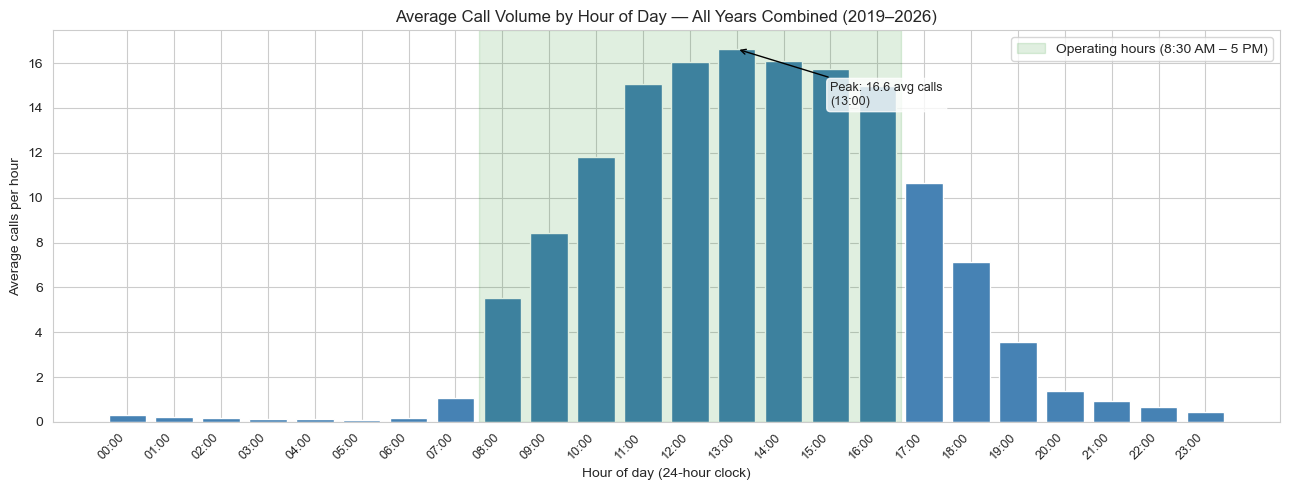


Average calls by hour:
ds
0     0.30
1     0.20
2     0.20
3     0.10
4     0.10
5     0.10
6     0.20
7     1.10
8     5.50
9     8.40
10   11.80
11   15.10
12   16.00
13   16.60
14   16.10
15   15.70
16   15.00
17   10.60
18    7.10
19    3.60
20    1.40
21    0.90
22    0.70
23    0.40


In [176]:
# Group by hour of day (0–23) and compute the average call count across all days
hour_of_day = df_hourly['ds'].dt.hour
avg_by_hour = df_hourly.groupby(hour_of_day)['y'].mean()

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(avg_by_hour.index, avg_by_hour.values, color='steelblue', width=0.8, edgecolor='white')

# Shade the official operating window: 8:30 AM – 5:00 PM (hours 8 through 16 when floored to the hour)
ax.axvspan(7.5, 16.5, alpha=0.12, color='green', label='Operating hours (8:30 AM – 5 PM)')

ax.set_xlabel('Hour of day (24-hour clock)')
ax.set_ylabel('Average calls per hour')
ax.set_title('Average Call Volume by Hour of Day — All Years Combined (2019–2026)')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=9)
ax.legend()

# Annotate the peak hour automatically
peak_hour = int(avg_by_hour.idxmax())
ax.annotate(
    f'Peak: {avg_by_hour[peak_hour]:.1f} avg calls\n({peak_hour:02d}:00)',
    xy=(peak_hour, avg_by_hour[peak_hour]),
    xytext=(peak_hour + 2, avg_by_hour[peak_hour] * 0.85),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

print('\nAverage calls by hour:')
print(avg_by_hour.round(1).to_string())

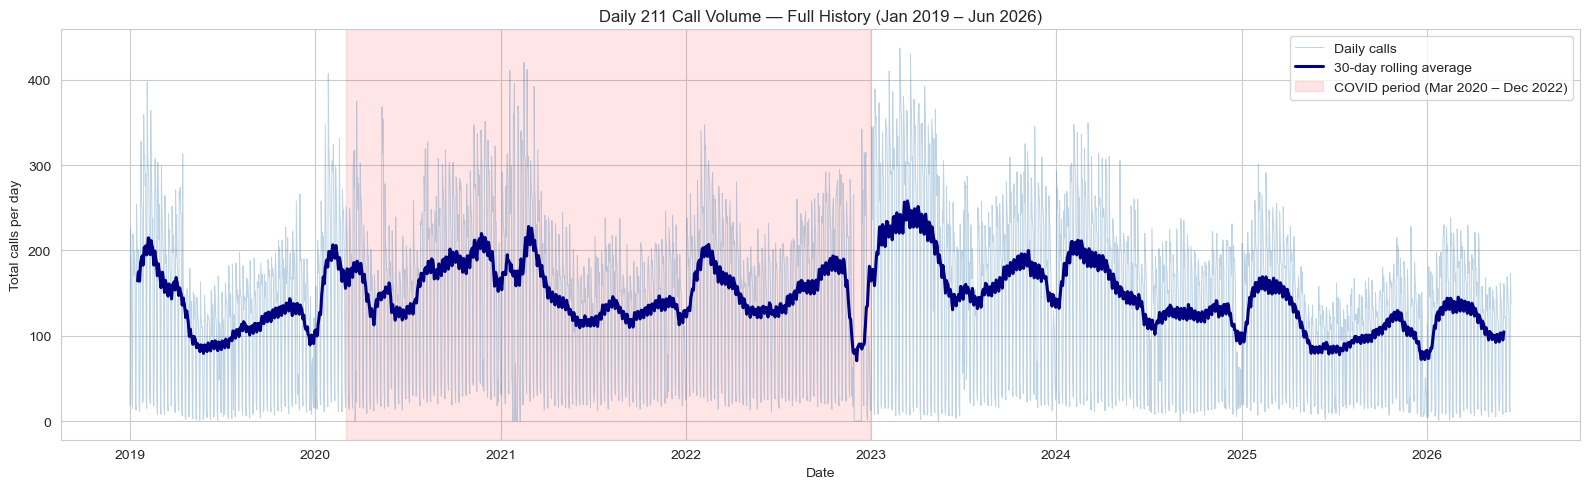

Daily stats:
  Mean : 146 calls/day
  Max  : 437 calls on 2023-02-27
  Zero-call days: 24


In [177]:
# Roll hourly counts up to daily totals — sum all hours within each calendar day
df_daily = df_hourly.resample('D', on='ds')['y'].sum().reset_index()
df_daily.columns = ['date', 'calls']

# 30-day rolling average: smooths out the spiky weekday/weekend pattern so trends are easier to see
df_daily['rolling_30d'] = df_daily['calls'].rolling(window=30, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))

# Raw daily counts — light/thin so the rolling average stands out
ax.plot(df_daily['date'], df_daily['calls'],
        color='steelblue', alpha=0.35, linewidth=0.7, label='Daily calls')

# 30-day rolling average — the "signal" underneath the noise
ax.plot(df_daily['date'], df_daily['rolling_30d'],
        color='navy', linewidth=2.2, label='30-day rolling average')

# Shade the COVID disruption period
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-12-31'),
           alpha=0.10, color='red', label='COVID period (Mar 2020 – Dec 2022)')

ax.set_xlabel('Date')
ax.set_ylabel('Total calls per day')
ax.set_title('Daily 211 Call Volume — Full History (Jan 2019 – Jun 2026)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()

plt.tight_layout()
plt.show()

print(f'Daily stats:')
print(f'  Mean : {df_daily["calls"].mean():.0f} calls/day')
print(f'  Max  : {df_daily["calls"].max():.0f} calls on {df_daily.loc[df_daily["calls"].idxmax(), "date"].date()}')
print(f'  Zero-call days: {(df_daily["calls"] == 0).sum()}')

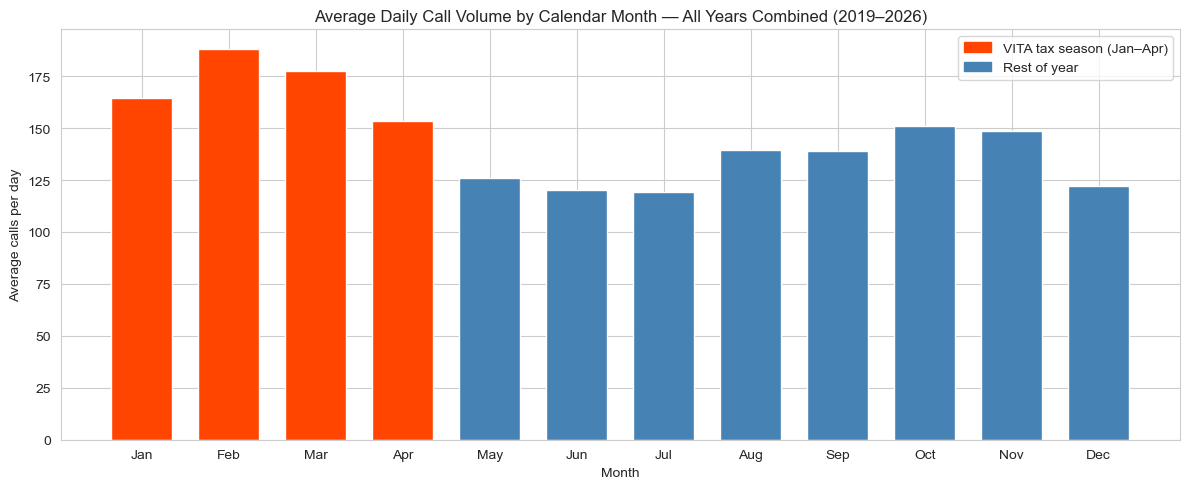

Average daily calls by month:
  Jan: 164
  Feb: 188
  Mar: 177
  Apr: 153
  May: 126
  Jun: 120
  Jul: 119
  Aug: 139
  Sep: 139
  Oct: 151
  Nov: 149
  Dec: 122


In [178]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Average daily calls per calendar month across all years
month_avg = df_daily.groupby(df_daily['date'].dt.month)['calls'].mean()

# Color VITA tax season (Jan–Apr) differently from the rest
colors = ['orangered' if m <= 4 else 'steelblue' for m in month_avg.index]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(month_avg.index, month_avg.values, color=colors, width=0.7, edgecolor='white')

ax.set_xlabel('Month')
ax.set_ylabel('Average calls per day')
ax.set_title('Average Daily Call Volume by Calendar Month — All Years Combined (2019–2026)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color='orangered', label='VITA tax season (Jan–Apr)'),
    plt.Rectangle((0, 0), 1, 1, color='steelblue', label='Rest of year'),
])

plt.tight_layout()
plt.show()

print('Average daily calls by month:')
for m, name in enumerate(month_names, 1):
    print(f'  {name}: {month_avg[m]:.0f}')

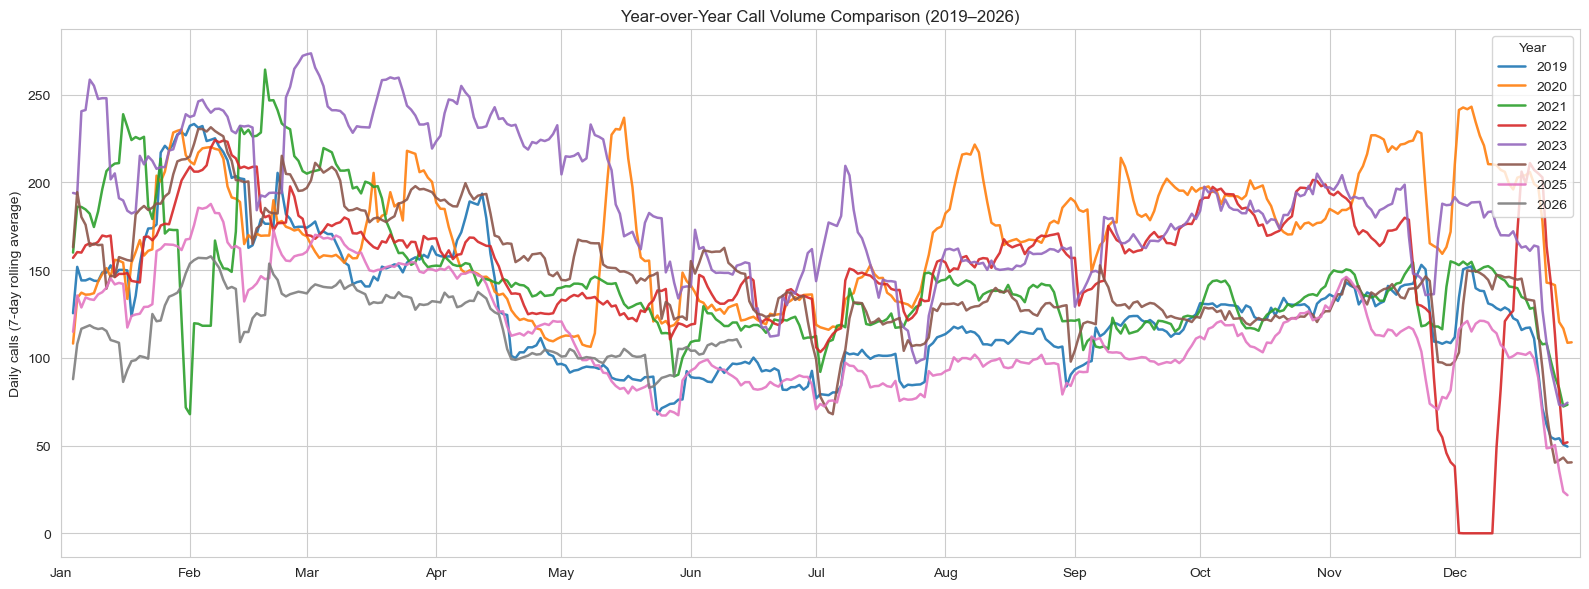

In [179]:
df_daily['year'] = df_daily['date'].dt.year
df_daily['day_of_year'] = df_daily['date'].dt.day_of_year

fig, ax = plt.subplots(figsize=(16, 6))

years = sorted(df_daily['year'].unique())
palette = plt.cm.tab10.colors

for i, year in enumerate(years):
    yr = df_daily[df_daily['year'] == year].sort_values('day_of_year')
    smoothed = yr['calls'].rolling(7, center=True).mean()
    ax.plot(yr['day_of_year'], smoothed, label=str(year),
            color=palette[i % len(palette)], linewidth=1.8, alpha=0.9)

# Approximate month start positions on the day-of-year axis
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels  = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_xlim(1, 365)

ax.set_ylabel('Daily calls (7-day rolling average)')
ax.set_title('Year-over-Year Call Volume Comparison (2019–2026)')
ax.legend(title='Year', loc='upper right')
plt.tight_layout()
plt.show()

In [180]:
dec_2022 = df_daily[
    (df_daily['date'].dt.year == 2022) &
    (df_daily['date'].dt.month == 12)
][['date', 'calls']].reset_index(drop=True)

dec_2022

,date,calls
0,2022-12-01,0
1,2022-12-02,0
2,2022-12-03,0
3,2022-12-04,0
4,2022-12-05,0
5,2022-12-06,0
6,2022-12-07,0
7,2022-12-08,0
8,2022-12-09,0
9,2022-12-10,0


### DATA PREPARATION

In [181]:
# Step 1: Filter to operating hours (8:30 AM – 5:00 PM)
# Floored to the hour, that's hours 8 through 16 — 9 slots per day
df_model = df_hourly[df_hourly['ds'].dt.hour.between(8, 16)].copy()

print(f'Before filter: {len(df_hourly):,} rows (24 hrs × day)')
print(f'After filter : {len(df_model):,} rows (9 hrs × day)')
print(f'\nHours kept: {sorted(df_model["ds"].dt.hour.unique())}')
print(f'Zero-call hours remaining: {(df_model["y"] == 0).sum():,}')
print(f'  (These are real — a slow hour during open time, not a closed center)')

Before filter: 64,842 rows (24 hrs × day)
After filter : 24,318 rows (9 hrs × day)

Hours kept: [np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16)]
Zero-call hours remaining: 2,783
  (These are real — a slow hour during open time, not a closed center)


In [182]:
# Step 2: df_model already has 'ds' and 'y' — exactly what Prophet requires
df_prophet = df_model[['ds', 'y']].copy()

# Step 3: COVID regressor — 1 only during March–December 2020
# YoY chart showed 2021 and 2022 were visually normal, so we don't penalise them
df_prophet['is_covid'] = (
    (df_prophet['ds'] >= '2020-03-01') &
    (df_prophet['ds'] <  '2021-01-01')
).astype(int)

# Step 4: US federal holiday flag
# Build a set of holiday dates for fast lookup, then check each row's date against it
us_holidays = holidays.US(years=df_prophet['ds'].dt.year.unique().tolist())
holiday_dates = set(us_holidays.keys())
df_prophet['is_holiday'] = df_prophet['ds'].dt.date.isin(holiday_dates).astype(int)

# ── Verification ────────────────────────────────────────────────────────────
print(f'Shape      : {df_prophet.shape}')
print(f'Columns    : {list(df_prophet.columns)}')
print(f'Date range : {df_prophet["ds"].min().date()}  →  {df_prophet["ds"].max().date()}')
print(f'COVID hrs  : {df_prophet["is_covid"].sum():,}  (Mar–Dec 2020)')
print(f'Holiday hrs: {df_prophet["is_holiday"].sum():,}  '
      f'({df_prophet["is_holiday"].sum() // 9} holiday dates × 9 hrs)')
print()
df_prophet.head(10)

Shape      : (24318, 4)
Columns    : ['ds', 'y', 'is_covid', 'is_holiday']
Date range : 2019-01-01  →  2026-06-16
COVID hrs  : 2,745  (Mar–Dec 2020)
Holiday hrs: 792  (88 holiday dates × 9 hrs)



,ds,y,is_covid,is_holiday
8,2019-01-01 08:00:00,1,0,1
9,2019-01-01 09:00:00,0,0,1
10,2019-01-01 10:00:00,2,0,1
11,2019-01-01 11:00:00,2,0,1
12,2019-01-01 12:00:00,1,0,1
13,2019-01-01 13:00:00,1,0,1
14,2019-01-01 14:00:00,1,0,1
15,2019-01-01 15:00:00,2,0,1
16,2019-01-01 16:00:00,2,0,1
32,2019-01-02 08:00:00,1,0,0


In [183]:
from datetime import date, timedelta

# ── VITA tax season: Jan 1 – Apr 15 each year ─────────────────────────────
df_prophet['is_vita'] = (
    (df_prophet['ds'].dt.month <= 3) |
    ((df_prophet['ds'].dt.month == 4) & (df_prophet['ds'].dt.day <= 15))
).astype(int)

# ── Utah Pioneer Day: July 24 ─────────────────────────────────────────────
df_prophet['is_pioneer_day'] = (
    (df_prophet['ds'].dt.month == 7) & (df_prophet['ds'].dt.day == 24)
).astype(int)

# ── Tax deadline: April 15 ────────────────────────────────────────────────
df_prophet['is_tax_deadline'] = (
    (df_prophet['ds'].dt.month == 4) & (df_prophet['ds'].dt.day == 15)
).astype(int)

# ── Day before / after any holiday (federal holidays + Pioneer Day) ────────
# holiday_dates was built in the previous cell from holidays.US()
pioneer_day_dates  = {date(yr, 7, 24) for yr in df_prophet['ds'].dt.year.unique()}
all_holiday_dates  = holiday_dates | pioneer_day_dates
day_before_set     = {d - timedelta(days=1) for d in all_holiday_dates}
day_after_set      = {d + timedelta(days=1) for d in all_holiday_dates}

df_prophet['is_day_before_holiday'] = df_prophet['ds'].dt.date.isin(day_before_set).astype(int)
df_prophet['is_day_after_holiday']  = df_prophet['ds'].dt.date.isin(day_after_set).astype(int)

# ── Sanity check ──────────────────────────────────────────────────────────
new_features = ['is_vita', 'is_pioneer_day', 'is_tax_deadline',
                'is_day_before_holiday', 'is_day_after_holiday']
for col in new_features:
    hrs = df_prophet[col].sum()
    print(f'{col:<25} : {hrs:>5,} hrs  (~{hrs // 9} days)')

is_vita                   : 7,506 hrs  (~834 days)
is_pioneer_day            :    63 hrs  (~7 days)
is_tax_deadline           :    72 hrs  (~8 days)
is_day_before_holiday     :   846 hrs  (~94 days)
is_day_after_holiday      :   855 hrs  (~95 days)


In [184]:
df_prophet.head(20)

,ds,y,is_covid,is_holiday,is_vita,is_pioneer_day,is_tax_deadline,is_day_before_holiday,is_day_after_holiday
8,2019-01-01 08:00:00,1,0,1,1,0,0,0,0
9,2019-01-01 09:00:00,0,0,1,1,0,0,0,0
10,2019-01-01 10:00:00,2,0,1,1,0,0,0,0
11,2019-01-01 11:00:00,2,0,1,1,0,0,0,0
12,2019-01-01 12:00:00,1,0,1,1,0,0,0,0
13,2019-01-01 13:00:00,1,0,1,1,0,0,0,0
14,2019-01-01 14:00:00,1,0,1,1,0,0,0,0
15,2019-01-01 15:00:00,2,0,1,1,0,0,0,0
16,2019-01-01 16:00:00,2,0,1,1,0,0,0,0
32,2019-01-02 08:00:00,1,0,0,1,0,0,0,1


### Modeling

In [185]:
# Train on everything up to May 3; hold out May 4 – Jun 2 as the test set (~30 days)
CUTOFF = pd.Timestamp('2026-05-04')

train = df_prophet[df_prophet['ds'] < CUTOFF].copy()
test  = df_prophet[df_prophet['ds'] >= CUTOFF].copy()

print(f'Training set : {len(train):,} hours  ({train["ds"].min().date()} → {train["ds"].max().date()})')
print(f'Test set     : {len(test):,} hours  ({test["ds"].min().date()} → {test["ds"].max().date()})')

Training set : 23,922 hours  (2019-01-01 → 2026-05-03)
Test set     : 396 hours  (2026-05-04 → 2026-06-16)


In [186]:
REGRESSORS = [
    'is_covid', 'is_holiday', 'is_vita', 'is_pioneer_day',
    'is_tax_deadline', 'is_day_before_holiday', 'is_day_after_holiday',
]

m = Prophet(
    seasonality_mode='multiplicative',  # spikes/dips scale with baseline, not fixed offsets
    changepoint_prior_scale=0.15,       # moderate trend flexibility
    daily_seasonality=True,             # learns the within-day hour pattern (8 AM vs 3 PM)
    weekly_seasonality=True,            # learns Mon–Sun pattern
    yearly_seasonality=True,            # learns the Jan–Apr VITA spike
)

for reg in REGRESSORS:
    m.add_regressor(reg)

print('Fitting Prophet on hourly data — this takes 1–3 minutes...')
m.fit(train)
print('Done.')

Fitting Prophet on hourly data — this takes 1–3 minutes...


17:15:57 - cmdstanpy - INFO - Chain [1] start processing
17:16:10 - cmdstanpy - INFO - Chain [1] done processing


Done.


Test set performance (May 4 – Jun 2, 2026):
  RMSE : 4.6 calls/hr
  MAE  : 3.5 calls/hr
  MAPE : 59.7%  (non-zero hours only)

  Non-zero hours evaluated: 366 of 396 total test hours


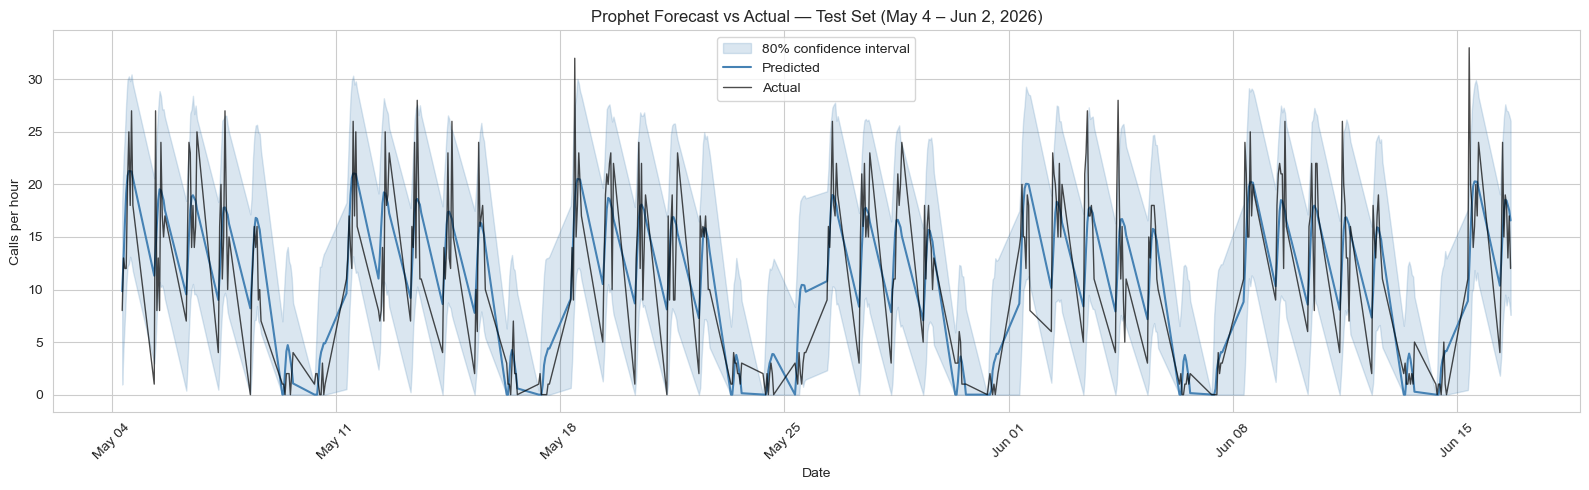

In [187]:
# ── Step 1: Generate predictions on the test set ─────────────────────────
forecast_test = m.predict(test)

# Prophet can predict small negative values near zero — clip them since calls can't be negative
results = test[['ds', 'y']].copy().reset_index(drop=True)
results['yhat']       = forecast_test['yhat'].clip(lower=0).values
results['yhat_lower'] = forecast_test['yhat_lower'].clip(lower=0).values
results['yhat_upper'] = forecast_test['yhat_upper'].clip(lower=0).values

# ── Step 2: Calculate accuracy metrics ───────────────────────────────────
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))
mae  = mean_absolute_error(results['y'], results['yhat'])

# MAPE: skip zero-actual hours to avoid dividing by zero
nonzero = results[results['y'] > 0]
mape = (np.abs(nonzero['y'] - nonzero['yhat']) / nonzero['y']).mean() * 100

print('Test set performance (May 4 – Jun 2, 2026):')
print(f'  RMSE : {rmse:.1f} calls/hr')
print(f'  MAE  : {mae:.1f} calls/hr')
print(f'  MAPE : {mape:.1f}%  (non-zero hours only)')
print()
print(f'  Non-zero hours evaluated: {len(nonzero)} of {len(results)} total test hours')

# ── Step 3: Plot actual vs predicted ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, color='steelblue', label='80% confidence interval')
ax.plot(results['ds'], results['yhat'], color='steelblue', linewidth=1.5, label='Predicted')
ax.plot(results['ds'], results['y'],    color='black',     linewidth=1,   alpha=0.7, label='Actual')

ax.set_xlabel('Date')
ax.set_ylabel('Calls per hour')
ax.set_title('Prophet Forecast vs Actual — Test Set (May 4 – Jun 2, 2026)')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

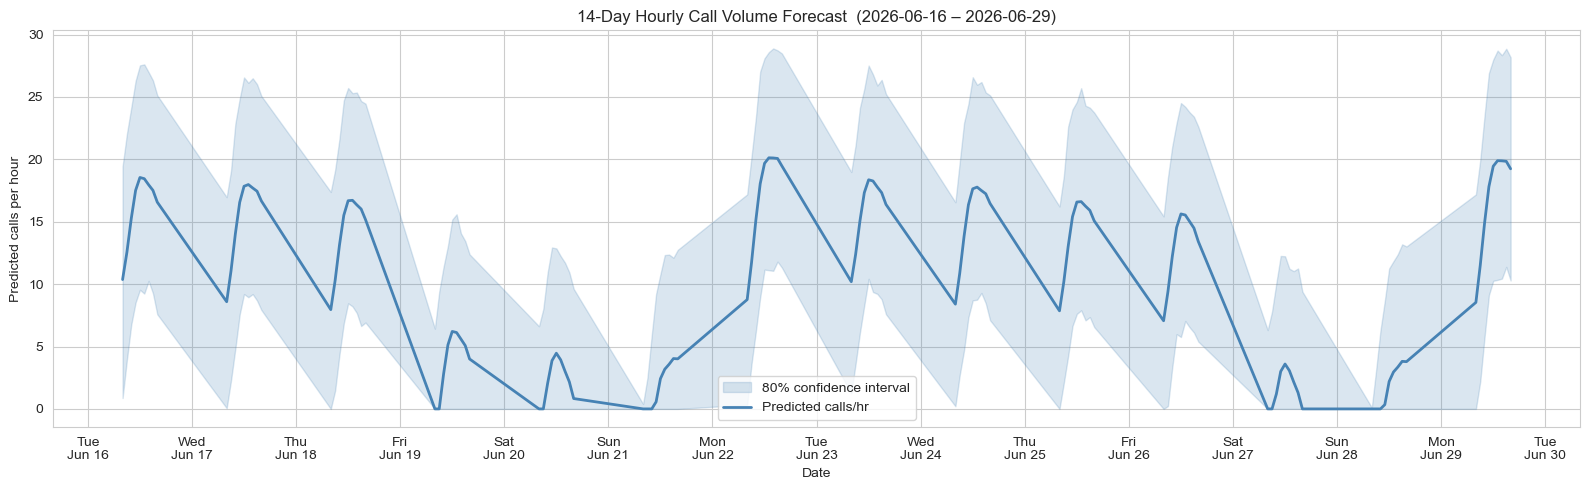

Daily forecast summary (2026-06-16 – 2026-06-29):
            predicted_calls  low_estimate  high_estimate
date                                                    
2026-06-16              145            66            225
2026-06-17              138            59            214
2026-06-18              128            51            208
2026-06-19               35             0            111
2026-06-20               20             0             96
2026-06-21               18             0             78
2026-06-22              153            76            231
2026-06-23              143            65            222
2026-06-24              136            57            213
2026-06-25              127            50            204
2026-06-26              117            40            196
2026-06-27               14             0             92
2026-06-28               16             0             80
2026-06-29              151            70            230


In [188]:
# ── Build 14-day future hourly timestamps (operating hours only) ──────────
FORECAST_START = pd.Timestamp('today').normalize()
FORECAST_END   = FORECAST_START + pd.Timedelta(days=13)

future_hours = pd.DatetimeIndex([
    FORECAST_START + pd.Timedelta(days=d, hours=h)
    for d in range(14)
    for h in range(8, 17)   # 8 AM through 4 PM slots → 9 hrs/day
])
future = pd.DataFrame({'ds': future_hours})

# ── Add regressors — same logic as training data ──────────────────────────
# Rebuild holiday lookup to ensure future year is covered
future_holiday_lookup = holidays.US(years=[FORECAST_START.year, FORECAST_END.year])
future_holiday_dates  = set(future_holiday_lookup.keys())

future['is_covid']   = 0  # COVID period was Mar–Dec 2020, long past
future['is_holiday'] = future['ds'].dt.date.isin(future_holiday_dates).astype(int)
future['is_vita']    = (
    (future['ds'].dt.month <= 3) |
    ((future['ds'].dt.month == 4) & (future['ds'].dt.day <= 15))
).astype(int)
future['is_pioneer_day']  = (
    (future['ds'].dt.month == 7) & (future['ds'].dt.day == 24)
).astype(int)
future['is_tax_deadline'] = (
    (future['ds'].dt.month == 4) & (future['ds'].dt.day == 15)
).astype(int)

future_pioneer_dates   = {date(yr, 7, 24) for yr in future['ds'].dt.year.unique()}
future_all_holidays    = future_holiday_dates | future_pioneer_dates
future['is_day_before_holiday'] = future['ds'].dt.date.isin(
    {d - timedelta(days=1) for d in future_all_holidays}
).astype(int)
future['is_day_after_holiday']  = future['ds'].dt.date.isin(
    {d + timedelta(days=1) for d in future_all_holidays}
).astype(int)

# ── Run the forecast ──────────────────────────────────────────────────────
forecast_future = m.predict(future)
forecast_future['yhat']       = forecast_future['yhat'].clip(lower=0)
forecast_future['yhat_lower'] = forecast_future['yhat_lower'].clip(lower=0)
forecast_future['yhat_upper'] = forecast_future['yhat_upper'].clip(lower=0)

# ── Plot: hourly forecast ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(forecast_future['ds'],
                forecast_future['yhat_lower'], forecast_future['yhat_upper'],
                alpha=0.2, color='steelblue', label='80% confidence interval')
ax.plot(forecast_future['ds'], forecast_future['yhat'],
        color='steelblue', linewidth=2, label='Predicted calls/hr')

ax.set_xlabel('Date')
ax.set_ylabel('Predicted calls per hour')
ax.set_title(f'14-Day Hourly Call Volume Forecast  ({FORECAST_START.date()} – {FORECAST_END.date()})')
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%b %d'))
ax.legend()
plt.tight_layout()
plt.show()

# ── Daily rollup summary table ────────────────────────────────────────────
forecast_future['date'] = forecast_future['ds'].dt.date
daily_fcast = (
    forecast_future
    .groupby('date')[['yhat', 'yhat_lower', 'yhat_upper']]
    .sum()
    .round(0)
    .astype(int)
)
daily_fcast.columns = ['predicted_calls', 'low_estimate', 'high_estimate']

print(f'Daily forecast summary ({FORECAST_START.date()} – {FORECAST_END.date()}):')
print(daily_fcast.to_string())

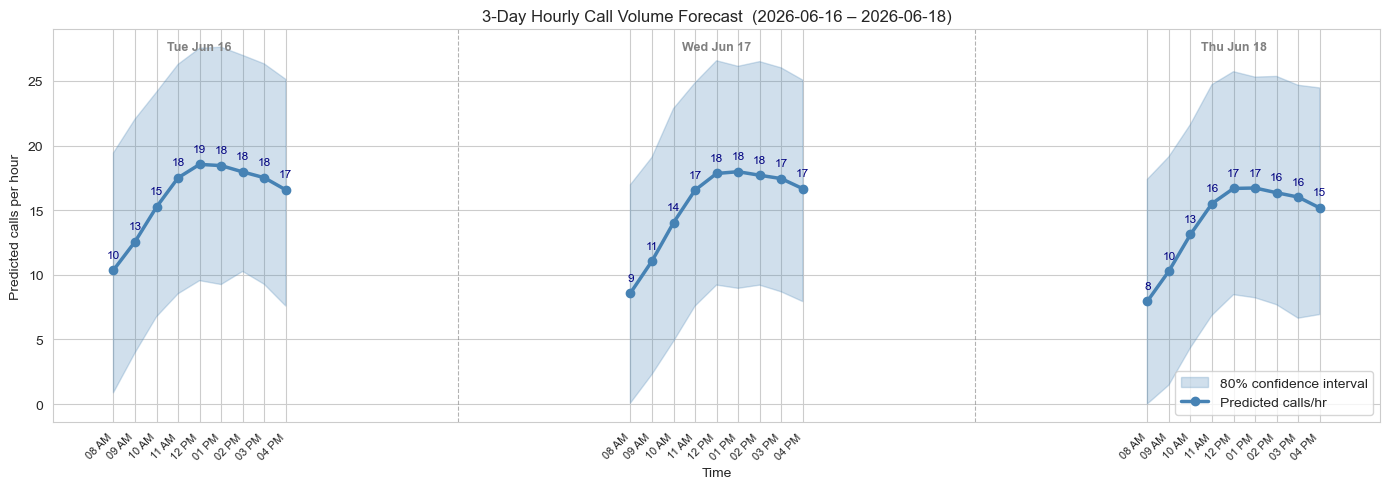

In [189]:
# Slice forecast_future down to the next 3 days
three_day_end = FORECAST_START + pd.Timedelta(days=2)
fcast_3day = forecast_future[forecast_future['ds'].dt.date <= three_day_end.date()].copy()

# Insert NaN rows between days so the line doesn't connect across the overnight gap
days = sorted(fcast_3day['ds'].dt.date.unique())
chunks = []
for i, d in enumerate(days):
    chunk = fcast_3day[fcast_3day['ds'].dt.date == d]
    chunks.append(chunk)
    if i < len(days) - 1:
        # NaN spacer row breaks the line without adding a real data point
        spacer = pd.DataFrame({'ds': [pd.NaT], 'yhat': [np.nan],
                               'yhat_lower': [np.nan], 'yhat_upper': [np.nan]})
        chunks.append(spacer)
plot_df = pd.concat(chunks, ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(plot_df['ds'], plot_df['yhat_lower'], plot_df['yhat_upper'],
                alpha=0.25, color='steelblue', label='80% confidence interval')
ax.plot(plot_df['ds'], plot_df['yhat'],
        color='steelblue', linewidth=2.5, marker='o', markersize=6, label='Predicted calls/hr')

# Label each point with its rounded value
for _, row in fcast_3day.iterrows():
    ax.annotate(f"{int(round(row['yhat']))}",
                xy=(row['ds'], row['yhat']),
                xytext=(0, 9), textcoords='offset points',
                ha='center', fontsize=8.5, color='navy')

ax.set_xlabel('Time')
ax.set_ylabel('Predicted calls per hour')
ax.set_title(f'3-Day Hourly Call Volume Forecast  ({FORECAST_START.date()} – {three_day_end.date()})')

# Set x-ticks to only the actual operating-hour timestamps — no overnight ticks
ax.set_xticks(fcast_3day['ds'])
ax.set_xticklabels(
    [ts.strftime('%I %p') for ts in fcast_3day['ds']],
    rotation=45, ha='right', fontsize=8
)

# Draw day-boundary lines and date labels
for d in days[1:]:
    sep = pd.Timestamp(d)
    ax.axvline(sep, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

for d in days:
    day_data = fcast_3day[fcast_3day['ds'].dt.date == d]
    mid_ts = day_data['ds'].iloc[len(day_data) // 2]
    ax.text(mid_ts, ax.get_ylim()[1] * 0.97,
            pd.Timestamp(d).strftime('%a %b %d'),
            ha='center', va='top', fontsize=9, fontweight='bold', color='gray')

ax.legend()
plt.tight_layout()
plt.show()